In [ ]:
import pandas as pd          # Loading data
import numpy as np           # Mathematical calculations
import re                    # Regular expressions for text cleaning
import nltk                  # NLP library
import matplotlib.pyplot as plt  # Visualization

from nltk.corpus import stopwords      # Remove stopwords
from nltk.tokenize import word_tokenize # Tokenization
from nltk.sentiment import SentimentIntensityAnalyzer # Sentiment analysis
from collections import Counter        # Count word frequencies
from wordcloud import WordCloud         # Generate word clouds

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("Customer Reviews dataset")
df.head()

Customer Reviews dataset


,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product. Worth the money.


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    print('lower case',text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]','',text)
    print('special character',text)

    # tokenization
    words = word_tokenize(text)
    print('tokenization',words)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    print('stopwords',words)

    # join words again
    cleaned_text = ' '.join(words)
    print('join',cleaned_text)

    return cleaned_text

df['cleaned_review']=df['Review'].apply(clean_text)

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
join product quality excellent delivery fast
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
join bad packaging item damaged
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
join customer service helpful responsive
lower case the delivery was delayed and support team did no

special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
join productqualityexcellentdeliveryfast


'productqualityexcellentdeliveryfast'

In [ ]:
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if compound >= 0.05:
    return 'Positive'
  elif compound <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'
df['sentiment']= df['cleaned_review'].apply(analyze_sentiment)

print(df[['Review','sentiment']])





                                              Review sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [ ]:
all_words = " ".join(df['cleaned_review'])
word_list = all_words.split()

word_freq = Counter(word_list)

print("\n Top 10 common keywords")
print(word_freq.most_common(10))



 Top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
negative_reviews = df[df['sentiment']== 'Negative']

negative_words = " ".join(negative_reviews['cleaned_review'])

negative_word_list = negative_words.split()

complaint_freq = Counter(negative_word_list)

print("\n Top 10 common negative keywords")
print(complaint_freq.most_common(10))



 Top 10 common negative keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


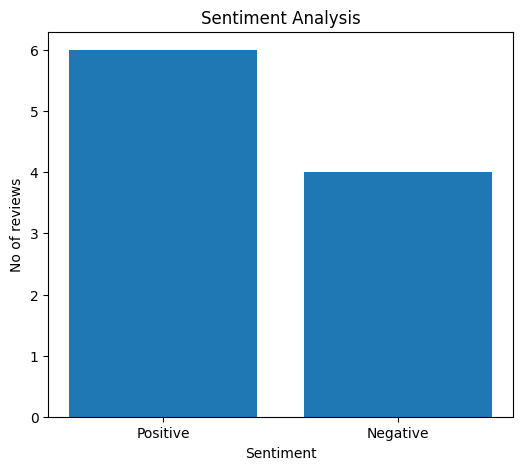

In [ ]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('No of reviews')
plt.title('Sentiment Analysis')
plt.show()

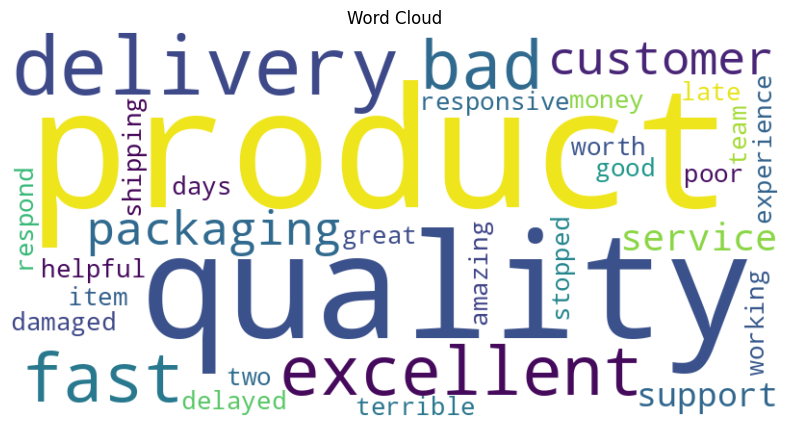

In [ ]:
wordcloud = WordCloud(
    width=800,
    height = 400,
    background_color = 'white'

).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()

